# 06 — Dimensionality Reduction

**Chapter 8 companion.** The ten peer features of notebook 05 are correlated: large
institutions tend to pay more, spend more per student, and rely less on tuition.
Principal component analysis (PCA) rewrites the features as uncorrelated components
ordered by the variance they explain. It is used here to answer three questions:
how many independent dimensions the data really has, what those dimensions mean,
and whether their interpretation survives resampling.

| | |
|---|---|
| Input | `data/analytic/institutions_2023.parquet`; `data/analytic/peer_groups.parquet` from notebook 05 (optional) |
| Features | `iu.peer_feature_matrix`, standardised: the same matrix used for clustering |
| Methods | Scree plot, Horn's parallel analysis, loadings, bootstrap loading uncertainty with sign alignment, component scores against an outcome |

In [1]:
import os
import sys
import warnings
from pathlib import Path

sys.path.insert(0, "../src")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import ipeds_utils as iu

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 40)
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")
plt.rcParams.update({
    "figure.dpi": 100, "figure.figsize": (8, 4.2),
    "axes.spines.top": False, "axes.spines.right": False, "axes.grid": True,
    "grid.alpha": 0.25, "font.size": 10,
})

ANALYTIC = Path("../data/analytic")
FIGURES = Path("../reports/figures")
ANALYTIC.mkdir(parents=True, exist_ok=True)
FIGURES.mkdir(parents=True, exist_ok=True)

SEED = 20231  # one seed for every stochastic step, so reruns reproduce exactly
rng = np.random.default_rng(SEED)


def save(name):
    """Save the current figure to reports/figures and display it."""
    plt.tight_layout()
    plt.savefig(FIGURES / f"{name}.png", dpi=150, bbox_inches="tight")
    plt.show()


print(f"ipeds_utils {iu.__version__} | pandas {pd.__version__} | numpy {np.__version__}")

ipeds_utils 1.1.0 | pandas 3.0.5 | numpy 2.5.3


In [2]:
source = ANALYTIC / "institutions_2023.parquet"
if not source.exists():
    raise FileNotFoundError("Run 01_ingest_clean_deidentify.ipynb first; it builds the analytic table.")

inst = pd.read_parquet(source)
inst = inst[inst["IN_UNIVERSE"]].copy()
print(f"{len(inst):,} institutions in the analysis universe")

5,988 institutions in the analysis universe


In [3]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

four = inst[inst["ICLEVEL"] == 1].set_index("UNITID")
X, _ = iu.peer_feature_matrix(four.reset_index())
Z = StandardScaler().fit_transform(X)
pca = PCA().fit(Z)
print(f"{Z.shape[0]:,} institutions x {Z.shape[1]} standardised features")

2,143 institutions x 10 standardised features


## 1. How many components? Parallel analysis

The rule "keep eigenvalues above 1" keeps too many components in samples like this,
because even pure noise produces some eigenvalues above 1. Horn's parallel analysis
makes the comparison explicit. It computes eigenvalues for random data of the same
shape, and keeps only the components whose eigenvalue exceeds the 95th percentile
of that noise.

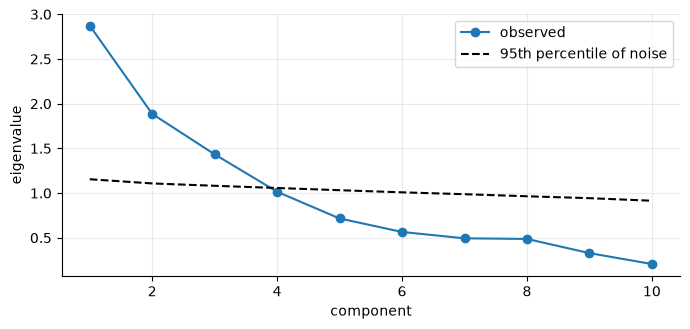

parallel analysis retains 3 components (62% of variance)


,eigenvalue,noise 95th pct,variance share,cumulative
PC1,2.874,1.155,0.287,0.287
PC2,1.886,1.108,0.188,0.476
PC3,1.433,1.082,0.143,0.619
PC4,1.015,1.057,0.101,0.720
PC5,0.716,1.032,0.072,0.792
PC6,0.565,1.008,0.056,0.848
PC7,0.494,0.987,0.049,0.898
PC8,0.487,0.964,0.049,0.947
PC9,0.328,0.943,0.033,0.979
PC10,0.206,0.914,0.021,1.000


In [4]:
eig = pca.explained_variance_
noise = np.array([
    PCA().fit(rng.standard_normal(Z.shape)).explained_variance_ for _ in range(200)
])
threshold = np.quantile(noise, 0.95, axis=0)
n_keep = int(np.argmax(eig < threshold)) if (eig < threshold).any() else len(eig)

scree = pd.DataFrame({"eigenvalue": eig, "noise 95th pct": threshold,
                      "variance share": pca.explained_variance_ratio_,
                      "cumulative": pca.explained_variance_ratio_.cumsum()},
                     index=[f"PC{i + 1}" for i in range(len(eig))])

fig, ax = plt.subplots(figsize=(7, 3.4))
ax.plot(range(1, len(eig) + 1), eig, "o-", label="observed")
ax.plot(range(1, len(eig) + 1), threshold, "k--", label="95th percentile of noise")
ax.set(xlabel="component", ylabel="eigenvalue")
ax.legend()
save("06_parallel_analysis")
print(f"parallel analysis retains {n_keep} components "
      f"({scree['cumulative'].iloc[n_keep - 1]:.0%} of variance)")
scree

The two rules disagree at PC4. Its eigenvalue of 1.02 passes the "above 1" rule but
falls below the noise threshold of 1.06, so parallel analysis keeps three components
covering 62% of the variance. Ten features carry about three independent dimensions
of information.

## 2. What the components mean

A loading is the weight a feature carries in a component. Components are defined
only up to sign, so each is oriented here so that its largest loading is positive.

In [5]:
def aligned(components):
    signs = np.sign(components[np.arange(len(components)), np.abs(components).argmax(axis=1)])
    return components * signs[:, None]


loadings = pd.DataFrame(aligned(pca.components_[:3]).T, index=X.columns, columns=["PC1", "PC2", "PC3"])
loadings.round(2).sort_values("PC1", key=np.abs, ascending=False)

,PC1,PC2,PC3
log_avg_salary,0.450,0.190,0.200
log_exp_per_fte,0.380,-0.420,0.010
tenure_density,0.370,0.220,0.080
tuition_share,-0.370,0.020,0.210
instr_fte_share,-0.350,0.130,0.450
pct_pell,-0.320,-0.070,-0.320
log_enroll,0.310,0.520,-0.060
pct_online,-0.210,0.310,-0.270
stu_fac_ratio,-0.090,0.530,-0.350
instr_exp_share,-0.090,0.250,0.640


PC1 is a resource-and-selectivity axis: higher salaries, spending per student, and
tenure density on one side; tuition dependence, Pell share, and a larger
instructional share of staff on the other. PC2 is scale without wealth: large
enrollment, high student-faculty ratios, and more online enrollment, but lower
spending per student. PC3 contrasts instruction-focused budgets and staffing with
high student-faculty ratios and Pell share.

## 3. Are the loadings stable?

A loading table with no uncertainty invites over-reading. Each bootstrap resamples
institutions, refits PCA, and aligns every component to the full-sample version
before recording it. Without alignment, sign flips between replicates inflate the
spread and make stable loadings look unstable.

In [6]:
reference = aligned(pca.components_[:3])
draws = []
for _ in range(300):
    idx = rng.integers(0, len(Z), len(Z))
    comp = PCA(n_components=3).fit(Z[idx]).components_
    comp *= np.sign((comp * reference).sum(axis=1))[:, None]
    draws.append(comp)
draws = np.array(draws)

boot_sd = pd.DataFrame(draws.std(axis=0).T, index=X.columns, columns=["PC1 sd", "PC2 sd", "PC3 sd"])
loadings.join(boot_sd).round(2)

,PC1,PC2,PC3,PC1 sd,PC2 sd,PC3 sd
log_enroll,0.310,0.520,-0.060,0.030,0.020,0.080
stu_fac_ratio,-0.090,0.530,-0.350,0.040,0.070,0.060
tuition_share,-0.370,0.020,0.210,0.010,0.040,0.040
instr_exp_share,-0.090,0.250,0.640,0.030,0.090,0.040
log_exp_per_fte,0.380,-0.420,0.010,0.030,0.040,0.080
instr_fte_share,-0.350,0.130,0.450,0.020,0.080,0.030
tenure_density,0.370,0.220,0.080,0.020,0.030,0.060
log_avg_salary,0.450,0.190,0.200,0.020,0.030,0.030
pct_online,-0.210,0.310,-0.270,0.030,0.040,0.070
pct_pell,-0.320,-0.070,-0.320,0.020,0.040,0.040


In [7]:
congruence = np.array([[abs(d[j] @ reference[j]) for j in range(3)] for d in draws])
pd.DataFrame({"median congruence": np.median(congruence, axis=0),
              "5th percentile": np.quantile(congruence, 0.05, axis=0)},
             index=["PC1", "PC2", "PC3"]).round(3)

,median congruence,5th percentile
PC1,0.997,0.991
PC2,0.991,0.956
PC3,0.988,0.958


The congruence coefficient is the absolute cosine between a bootstrap component and
the full-sample component. Values above about 0.95 are conventionally read as the
same component. A component that falls well below that in some replicates is
exchanging variance with a neighbour of similar eigenvalue, and its individual
loadings should not be interpreted. Here all three retained components stay above
0.95 in at least 95% of replicates, and no bootstrap SD for a loading reaches 0.1.
The interpretation in section 2 is stable.

## 4. Scores, sectors, and peer groups

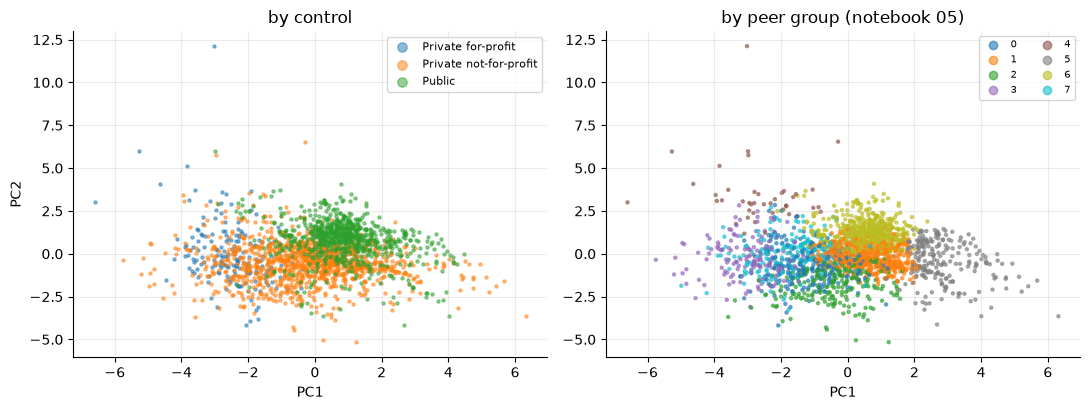

In [8]:
scores = pd.DataFrame(pca.transform(Z)[:, :2] * np.sign(pca.components_[:2][np.arange(2),
                      np.abs(pca.components_[:2]).argmax(axis=1)]),
                      index=X.index, columns=["PC1", "PC2"])
scores = scores.join(four[["CONTROL_LABEL", "BA_RATE_150", "RET_PCF"]])

peer_path = ANALYTIC / "peer_groups.parquet"
has_peers = peer_path.exists()
if has_peers:
    scores = scores.join(pd.read_parquet(peer_path).set_index("UNITID")["PEER_GROUP"])

fig, axes = plt.subplots(1, 2 if has_peers else 1, figsize=(11 if has_peers else 6, 4.2), squeeze=False)
for label, g in scores.groupby("CONTROL_LABEL"):
    axes[0, 0].scatter(g["PC1"], g["PC2"], s=5, alpha=0.5, label=label)
axes[0, 0].set(xlabel="PC1", ylabel="PC2", title="by control")
axes[0, 0].legend(markerscale=3, fontsize=8)
if has_peers:
    sc = axes[0, 1].scatter(scores["PC1"], scores["PC2"], c=scores["PEER_GROUP"], cmap="tab10", s=5, alpha=0.6)
    axes[0, 1].set(xlabel="PC1", title="by peer group (notebook 05)")
    axes[0, 1].legend(*sc.legend_elements(), fontsize=7, ncol=2)
else:
    print("peer_groups.parquet not found; run notebook 05 for the second panel")
save("06_scores")

## 5. Do the components relate to outcomes?

PCA never sees outcomes, so a correlation between a component and graduation rate
is a test of whether the dominant axis of institutional variation matters for
students. Correlation is not effect: the components mix selectivity, wealth, and
mission, all of which travel together.

In [9]:
from scipy import stats

rows = []
for outcome in ["BA_RATE_150", "RET_PCF"]:
    for pc in ["PC1", "PC2"]:
        ok = scores[[pc, outcome]].dropna()
        r = stats.spearmanr(ok[pc], ok[outcome])
        rows.append({"outcome": outcome, "component": pc, "institutions": len(ok),
                     "Spearman rho": r.statistic, "p": r.pvalue})
pd.DataFrame(rows)

,outcome,component,institutions,Spearman rho,p
0,BA_RATE_150,PC1,1764,0.592,0.000
1,BA_RATE_150,PC2,1764,-0.060,0.012
2,RET_PCF,PC1,1837,0.495,0.000
3,RET_PCF,PC2,1837,-0.026,0.274


PC1 correlates strongly with the bachelor's graduation rate (rho 0.59) and retention
(0.50). PC2 is essentially unrelated to either: its correlation with graduation rate
is statistically detectable but negligible (-0.06), and its correlation with
retention is not significant. The resource axis tracks outcomes; the scale axis does
not. This pattern is why notebook 10 benchmarks within peer groups: comparing across
PC1 mostly rediscovers institutional wealth.

## Exercises

1. Drop `pct_online` and refit. Does parallel analysis retain a different number of
   components, and does PC1 change meaning?
2. Fit PCA separately for public and private institutions. Compare PC1 loadings with
   the congruence coefficient. Is the main axis of variation the same in both?
3. Run k-means from notebook 05 on the retained component scores instead of the ten
   features. Compare the partitions with the adjusted Rand index.